<a href="https://colab.research.google.com/github/TribuneAlpha/2026_Spring_classes/blob/main/W5HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# load Boston Housing Dataset
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets, model_selection
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error

df = pd.read_csv("BostonHousing.csv")


In [12]:
df = df.rename(columns={"medv":"TARGET", 'rm':'RM','lstat':"LSTAT"})

df[["LSTAT", 'RM', "TARGET"]].head()

,LSTAT,RM,TARGET
0,4.98,6.575,24.0
1,9.14,6.421,21.6
2,4.03,7.185,34.7
3,2.94,6.998,33.4
4,5.33,7.147,36.2


Text(0, 0.5, 'target')

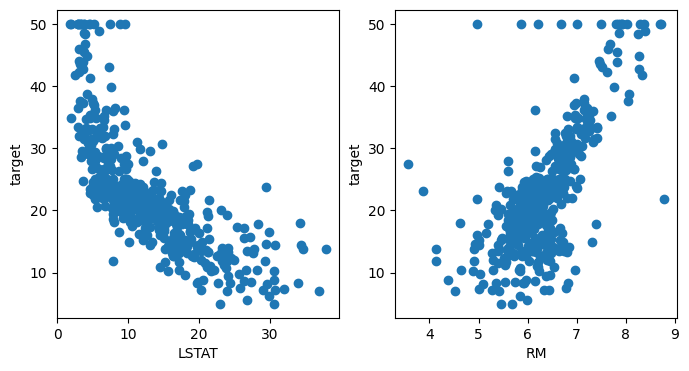

In [17]:
# showcase data
plt.figure(figsize=(8,4))

features = df[["LSTAT", 'RM']]
target = df['TARGET']

plt.subplot(1,2,1)
plt.scatter(df["LSTAT"], target)
plt.xlabel('LSTAT')
plt.ylabel("target")

plt.subplot(1,2,2)
plt.scatter(df["RM"], target)
plt.xlabel('RM')
plt.ylabel("target")

In [27]:
from sklearn.linear_model import LinearRegression
# spit into testing/training
X_train, X_test, Y_train, Y_test = train_test_split(features,
                                                    target,
                                                    test_size=0.2,
                                                    random_state = 23)
model = LinearRegression()

model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)

Text(0, 0.5, 'predicted y')

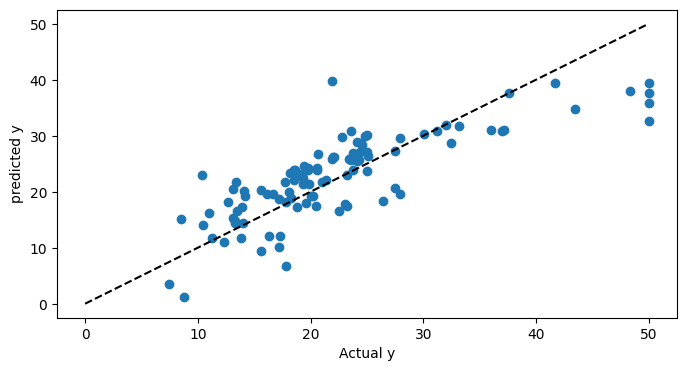

In [38]:
plt.figure(figsize=(8,4))
plt.scatter(Y_test, Y_pred)
plt.plot([0,50],[0,50], '--k', label = "correct prediction")
plt.xlabel('Actual y')
plt.ylabel('predicted y')

In [29]:
intercept = model.intercept_
coff = model.coef_
print("intercept", intercept)
print("coefficent", coff)

intercept 0.37428615187841885
coefficent [-0.66721079  4.88331552]


In [31]:
mse = mean_squared_error(Y_test, Y_pred)
print("Mean Squared Error:", mse)

mae = mean_absolute_error(Y_test, Y_pred)
print("Mean Absolute Error:", mae)

r2 = r2_score(Y_test, Y_pred)
print('R2 Score', r2)

Mean Squared Error: 30.726065211573893
Mean Absolute Error: 4.300122669036365
R2 Score 0.6433023932639312


In [35]:
new_houses_data = {
    'LSTAT': [5.0, 4.0, 15.0],
    'RM': [7, 6, 8]
}
new_houses_df = pd.DataFrame(new_houses_data)
new_houses_df

,LSTAT,RM
0,5.0,7
1,4.0,6
2,15.0,8


In [36]:
predicted_houses_prices = model.predict(new_houses_df)
predicted_houses_prices

array([31.22144086, 27.00533613, 29.43264846])

In [37]:
new_houses_df['Predicted Prices'] = predicted_houses_prices
new_houses_df

,LSTAT,RM,Predicted Prices
0,5.0,7,31.221441
1,4.0,6,27.005336
2,15.0,8,29.432648
